# Bolão Copa do Mundo FIFA 2026 — Previsão de placares com Rede Neural (TensorFlow/Keras)

**Aluno:** Bruno Aires &nbsp;|&nbsp; **Turma:** 2º BIM 2026

Pipeline reprodutível que treina uma **rede neural de regressão de Poisson** para prever os
placares exatos dos **24 jogos da 1ª rodada da fase de grupos** da Copa do Mundo 2026 e exporta
o resultado em JSON no formato exigido por `bolao_copa.txt`.

## 1. Introdução

**Hipótese do modelo.** O número de gols marcados por cada seleção em uma partida é uma
**contagem discreta não-negativa** que pode ser modelada por uma distribuição de **Poisson**,
cujo parâmetro de intensidade $\lambda$ (gols esperados) é uma **função não-linear** da força
relativa entre as equipes. Essa força é capturada por: rating **Elo** (construído
cronologicamente sobre 20 anos de jogos), **ranking/pontos FIFA**, **forma recente**
(gols pró/contra e aproveitamento nos últimos jogos) e a **probabilidade implícita do mercado de
apostas** (odds 1/X/2 convertidas). A vantagem de mando de campo **não é ajustada manualmente**:
fornecemos apenas a *feature* `neutral` (e o status de país-sede) e deixamos a rede aprender o efeito.

**Abordagem.** Uma rede densa recebe o vetor de atributos do confronto e produz **dois valores**
$(\lambda_A, \lambda_B)$ — gols esperados de cada seleção — via ativação `softplus` (garante
$\lambda>0$). O treinamento minimiza a **log-verossimilhança negativa de Poisson**. Cada partida
histórica é ponderada por **decay temporal** (ênfase nos últimos 2 anos). Para seleções com
histórico esparso aplicamos **transfer learning** por confederação (encolhimento bayesiano
das estatísticas em direção à média da confederação). A previsão final de cada jogo é um
**placar inteiro determinístico**: a **moda** da Poisson de cada $\lambda$, restrita ao intervalo
histórico realista $[0,5]$. **Todas as previsões derivam exclusivamente da rede neural** — nenhuma
regra simples, média direta ou ensemble com o mercado é usada na geração do placar.

### Configuração e reprodutibilidade

Fixamos *seeds* em `PYTHONHASHSEED`, `random`, `numpy` e `tensorflow`, e habilitamos operações
determinísticas no TF. Assim, execuções subsequentes do notebook produzem **exatamente os mesmos
resultados**.

In [1]:
import os, random, json, io, warnings
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from scipy.stats import poisson

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("determinism aviso:", e)

print("TensorFlow:", tf.__version__, "| NumPy:", np.__version__, "| Pandas:", pd.__version__)

TensorFlow: 2.20.0 | NumPy: 2.1.3 | Pandas: 3.0.3


## 2. Calendário e dados dos jogos

Coletamos o calendário oficial da 1ª rodada da fase de grupos (datas, horários, sedes, grupos e
pareamentos). O notebook **tenta um fetch online** (FIFA/fonte agregadora) e, em caso de falha de
rede, recorre a uma **tabela embutida** transcrita do material oficial do bolão (`bolao_copa.txt`)
e do documento de cotações. Isso garante reprodutibilidade offline. A ordem `jogo1..jogo24` segue
exatamente a do arquivo `bolao_copa.txt`.

In [2]:
# Confrontos oficiais (ordem jogo1..jogo24 = bolao_copa.txt). Datas/horários do material oficial.
# host=True indica seleção-sede jogando em seu país (efeito de mando capturado pela feature neutral).
FIXTURES = [
    # jogo, sigla_A, sigla_B, data,        hora,    grupo, A_é_sede
    (1,  "MEX","RSA","2026-06-11","16:00","A", True ),
    (2,  "KOR","CZE","2026-06-11","23:00","E", False),
    (3,  "CAN","BIH","2026-06-12","16:00","B", True ),
    (4,  "USA","PAR","2026-06-12","22:00","D", True ),
    (5,  "HAI","SCO","2026-06-13","22:00","?", False),
    (6,  "AUS","TUR","2026-06-14","01:00","?", False),
    (7,  "BRA","MAR","2026-06-13","19:00","?", False),
    (8,  "QAT","SUI","2026-06-13","16:00","?", False),
    (9,  "CIV","ECU","2026-06-14","13:00","?", False),
    (10, "GER","CUW","2026-06-14","14:00","?", False),
    (11, "NED","JPN","2026-06-14","17:00","?", False),
    (12, "SWE","TUN","2026-06-14","23:00","?", False),
    (13, "KSA","URU","2026-06-15","19:00","?", False),
    (14, "ESP","CPV","2026-06-15","13:00","?", False),
    (15, "IRN","NZL","2026-06-15","22:00","?", False),
    (16, "BEL","EGY","2026-06-15","16:00","?", False),
    (17, "FRA","SEN","2026-06-16","16:00","?", False),
    (18, "IRQ","NOR","2026-06-16","19:00","?", False),
    (19, "ARG","ALG","2026-06-16","22:00","?", False),
    (20, "AUT","JOR","2026-06-17","01:00","?", False),
    (21, "GHA","PAN","2026-06-17","20:00","?", False),
    (22, "ENG","CRO","2026-06-17","17:00","?", False),
    (23, "POR","COD","2026-06-17","14:00","?", False),
    (24, "UZB","COL","2026-06-17","23:00","?", False),
]

import requests
def fetch_calendar():
    "Tenta obter o calendário online; retorna None em qualquer falha (usa-se o fallback embutido)."
    try:
        url = "https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_group_stage"
        r = requests.get(url, timeout=8, headers={"User-Agent":"Mozilla/5.0"})
        r.raise_for_status()
        return r.text  # parsing detalhado fora do escopo: validamos disponibilidade da fonte
    except Exception as e:
        print("[calendario] fetch online indisponivel -> usando tabela embutida:", repr(e)[:80])
        return None

_html = fetch_calendar()
print("Fonte online acessivel." if _html else "Operando offline com calendario embutido.")

cal = pd.DataFrame(FIXTURES, columns=["jogo","A","B","data","hora","grupo","A_sede"])
cal["confronto"] = cal["A"] + " x " + cal["B"]
print(f"\n{len(cal)} jogos da 1a rodada carregados.")
cal[["jogo","data","hora","grupo","confronto"]]

[calendario] fetch online indisponivel -> usando tabela embutida: HTTPError('404 Client Error: Not Found for url: https://en.wikipedia.org/wiki/20
Operando offline com calendario embutido.

24 jogos da 1a rodada carregados.


,jogo,data,hora,grupo,confronto
0,1,2026-06-11,16:00,A,MEX x RSA
1,2,2026-06-11,23:00,E,KOR x CZE
2,3,2026-06-12,16:00,B,CAN x BIH
3,4,2026-06-12,22:00,D,USA x PAR
4,5,2026-06-13,22:00,?,HAI x SCO
5,6,2026-06-14,01:00,?,AUS x TUR
6,7,2026-06-13,19:00,?,BRA x MAR
7,8,2026-06-13,16:00,?,QAT x SUI
8,9,2026-06-14,13:00,?,CIV x ECU
9,10,2026-06-14,14:00,?,GER x CUW


## 3. Fontes de dados

| Fonte | Conteúdo | Obtenção | Uso |
|---|---|---|---|
| **`results.csv`** (martj42/international_results) | 49 mil partidas internacionais 1872→hoje (gols, torneio, sede, neutro) | fetch GitHub → *fallback* arquivo local | Elo, forma recente, alvos de treino |
| **`fifa_ranking.csv`** | Ranking FIFA histórico (rank, pontos, confederação) | arquivo local | força absoluta + confederação (transfer learning) |
| **`shootouts.csv`** | Disputas de pênalti | arquivo local | contexto (não usado como alvo) |
| **`Copa_do_Mundo_Cotacoes.pdf`** | Odds 1/X/2 dos 24 jogos (ponto único no tempo) | leitura do PDF → dict transcrito | **feature de entrada direta** (prob. implícita) |

**Período coletado:** últimos **20 anos** de partidas oficiais e amistosos (Copa, eliminatórias,
torneios continentais e amistosos). Partidas mais antigas **não são descartadas** do cálculo de
Elo, mas entram no treino com **peso decrescente** (decay).

**Critérios de inclusão/exclusão (treino):** partidas com placar válido e data nos últimos 20 anos;
descartam-se registros sem placar. O Elo, porém, é construído sobre **todo** o histórico para
estabilizar os ratings iniciais.

**Decay weighting:** cada partida recebe peso $w = 0.5^{\,\Delta t / h}$ (meia-vida $h=2$ anos),
de modo que jogos dos **últimos 2 anos** dominam o ajuste e jogos antigos são desenfatizados.

**Transfer learning (cold-start):** seleções com poucos jogos no período (ex.: Curaçao, Cabo Verde)
têm estatísticas de forma/pontos **encolhidas em direção à média da sua confederação**
(estimador empírico-Bayes $\hat\theta = \frac{n\,\theta_{time} + k\,\theta_{conf}}{n+k}$),
suprindo a falta de amostras com o comportamento típico de seleções análogas.

In [3]:
DATA_DIR = "data"
RESULTS_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

def load_results():
    "Tenta baixar results.csv atualizado; em falha usa a cópia local."
    try:
        df = pd.read_csv(RESULTS_URL, parse_dates=["date"])
        print("[results] baixado online:", df.shape)
    except Exception as e:
        print("[results] fetch falhou -> usando arquivo local:", repr(e)[:70])
        df = pd.read_csv(os.path.join(DATA_DIR, "results.csv"), parse_dates=["date"])
        print("[results] local:", df.shape)
    return df

raw = load_results()
fifa = pd.read_csv(os.path.join(DATA_DIR, "fifa_ranking.csv"), parse_dates=["rank_date"])
print("[fifa_ranking]:", fifa.shape)
raw.head(3)

[results] baixado online: (49329, 9)
[fifa_ranking]: (62424, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False


### 3.1 Odds de mercado → probabilidades implícitas

O documento `Copa_do_Mundo_Cotacoes.pdf` é uma **imagem** (sem camada de texto); as cotações foram
**lidas e transcritas** para o dicionário abaixo (um único conjunto genérico 1/X/2 por jogo, no
ponto mais recente disponível — tratado como **feature agregada única**, conforme especificado).

Conversão para probabilidade implícita com **remoção da margem** (overround):
$p_i = \dfrac{1/o_i}{\sum_j 1/o_j}$. As três probabilidades $(p_1, p_X, p_2)$ entram **diretamente**
como atributos de entrada da rede.

In [4]:
# Odds 1 / X / 2 transcritas do PDF (Copa_do_Mundo_Cotacoes.pdf)
ODDS = {
    1:(1.50,4.25,6.90),  2:(2.75,3.10,2.75),  3:(1.83,3.65,4.40),  4:(2.05,3.35,3.75),
    5:(6.60,4.35,1.50),  6:(4.40,3.80,1.78),  7:(1.62,3.80,5.80),  8:(10.75,5.60,1.28),
    9:(3.85,2.85,2.30),  10:(1.04,14.50,55.00), 11:(1.98,3.75,3.60), 12:(1.95,3.35,4.15),
    13:(6.50,4.35,1.50), 14:(1.09,10.00,30.00), 15:(1.93,3.45,4.15), 16:(1.67,3.85,5.10),
    17:(1.47,4.40,6.80), 18:(11.00,5.90,1.26), 19:(1.42,4.50,8.25), 20:(1.37,5.20,8.00),
    21:(1.98,3.55,3.80), 22:(1.78,3.70,4.55), 23:(1.28,5.70,10.75), 24:(7.90,4.50,1.42),
}
def odds_to_prob(o1, ox, o2):
    inv = np.array([1.0/o1, 1.0/ox, 1.0/o2])
    return inv / inv.sum()           # [p1, pX, p2] sem overround

imp = {j: odds_to_prob(*o) for j, o in ODDS.items()}
cal[["imp_1","imp_x","imp_2"]] = np.vstack([imp[int(j)] for j in cal["jogo"]])
print("Probabilidades implicitas (amostra):")
cal[["jogo","confronto","imp_1","imp_x","imp_2"]].head(6)

Probabilidades implicitas (amostra):


,jogo,confronto,imp_1,imp_x,imp_2
0,1,MEX x RSA,0.636808,0.224756,0.138436
1,2,KOR x CZE,0.346369,0.307263,0.346369
2,3,CAN x BIH,0.521573,0.261501,0.216927
3,4,USA x PAR,0.463262,0.283489,0.253250
4,5,HAI x SCO,0.144566,0.219342,0.636092
5,6,AUS x TUR,0.215992,0.250096,0.533912


## 4. Pré-processamento

Etapas: (1) limpeza e padronização de nomes país↔sigla FIFA; (2) mapa de confederação;
(3) **construção cronológica do Elo** e da **forma recente** (sem vazamento: features são o estado
*pré-jogo*); (4) junção do **ranking FIFA** vigente na data; (5) **probabilidade implícita** —
para os jogos-alvo usamos as odds reais; para o histórico de treino usamos um *proxy* coerente
derivado do Elo (mesma semântica de $p_1/p_X/p_2$), garantindo distribuição de features consistente
entre treino e inferência; (6) **decay weighting**; (7) normalização. **Nenhum ajuste manual de
mando de campo** — apenas a feature `neutral`.

In [5]:
# 4.1 Padronização de nomes (results.csv usa nome completo; fixtures usam sigla FIFA)
# Renomeia nomes do fifa_ranking que diferem do results.csv para unificar a chave de junção.
FIFA_RENAME = {"Korea Republic":"South Korea","USA":"United States","Côte d'Ivoire":"Ivory Coast",
               "Cabo Verde":"Cape Verde","IR Iran":"Iran","Congo DR":"DR Congo","China PR":"China",
               "Kyrgyz Republic":"Kyrgyzstan","Cape Verde Islands":"Cape Verde"}
fifa["country_full"] = fifa["country_full"].replace(FIFA_RENAME)

# sigla FIFA (das fixtures) -> nome no results.csv
ABRV2NAME = {"MEX":"Mexico","RSA":"South Africa","KOR":"South Korea","CZE":"Czech Republic",
    "CAN":"Canada","BIH":"Bosnia and Herzegovina","USA":"United States","PAR":"Paraguay",
    "HAI":"Haiti","SCO":"Scotland","AUS":"Australia","TUR":"Turkey","BRA":"Brazil","MAR":"Morocco",
    "QAT":"Qatar","SUI":"Switzerland","CIV":"Ivory Coast","ECU":"Ecuador","GER":"Germany",
    "CUW":"Curaçao","NED":"Netherlands","JPN":"Japan","SWE":"Sweden","TUN":"Tunisia",
    "KSA":"Saudi Arabia","URU":"Uruguay","ESP":"Spain","CPV":"Cape Verde","IRN":"Iran",
    "NZL":"New Zealand","BEL":"Belgium","EGY":"Egypt","FRA":"France","SEN":"Senegal","IRQ":"Iraq",
    "NOR":"Norway","ARG":"Argentina","ALG":"Algeria","AUT":"Austria","JOR":"Jordan","GHA":"Ghana",
    "PAN":"Panama","ENG":"England","CRO":"Croatia","POR":"Portugal","COD":"DR Congo",
    "UZB":"Uzbekistan","COL":"Colombia"}

# mapa nome->confederação (para transfer learning); default 'OTHER'
name2conf = (fifa.sort_values("rank_date").drop_duplicates("country_full", keep="last")
                 .set_index("country_full")["confederation"].to_dict())
def conf_of(name): return name2conf.get(name, "OTHER")

# 4.2 limpeza
df = raw.dropna(subset=["home_score","away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
df = df.sort_values("date").reset_index(drop=True)
DATA_MAX = df["date"].max()
print("Periodo:", df["date"].min().date(), "->", DATA_MAX.date(), "| jogos:", len(df))

Periodo: 1872-11-30 -> 2026-03-31 | jogos: 49257


In [6]:
# 4.3 Passo cronológico: Elo + forma recente (estado PRÉ-jogo => sem vazamento)
from collections import deque, defaultdict
K_FORM, ELO_BASE, ELO_K = 6, 1500.0, 30.0
elo = defaultdict(lambda: ELO_BASE)
form = defaultdict(lambda: deque(maxlen=K_FORM))   # (gf, ga, pts)
cnt  = defaultdict(int)

def form_stats(t):
    dq = form[t]
    if not dq: return (np.nan, np.nan, np.nan)
    a = np.asarray(dq, float)
    return (a[:,0].mean(), a[:,1].mean(), a[:,2].mean())

cols = {k: [] for k in ["elo_h","elo_a","f_gf_h","f_ga_h","f_ppg_h","f_gf_a","f_ga_a","f_ppg_a"]}
for h, a, hs, asc in zip(df["home_team"], df["away_team"], df["home_score"], df["away_score"]):
    eh, ea = elo[h], elo[a]
    gfh, gah, pph = form_stats(h); gfa, gaa, ppa = form_stats(a)
    cols["elo_h"].append(eh); cols["elo_a"].append(ea)
    cols["f_gf_h"].append(gfh); cols["f_ga_h"].append(gah); cols["f_ppg_h"].append(pph)
    cols["f_gf_a"].append(gfa); cols["f_ga_a"].append(gaa); cols["f_ppg_a"].append(ppa)
    # atualiza Elo (com fator de margem de gols)
    exp_h = 1.0 / (1.0 + 10 ** (-(eh - ea) / 400.0))
    res_h = 1.0 if hs > asc else (0.5 if hs == asc else 0.0)
    delta = ELO_K * (np.log1p(abs(hs - asc)) + 1.0) * (res_h - exp_h)
    elo[h] = eh + delta; elo[a] = ea - delta
    # atualiza forma
    ph = 3 if hs > asc else (1 if hs == asc else 0)
    pa = 3 if asc > hs else (1 if hs == asc else 0)
    form[h].append((hs, asc, ph)); form[a].append((asc, hs, pa))
    cnt[h] += 1; cnt[a] += 1

for k, v in cols.items():
    df[k] = v
ELO_FINAL = dict(elo)   # estado final por seleção (usado nas fixtures)
print("Elo construido. Top-8 atual:")
for t, r in sorted(ELO_FINAL.items(), key=lambda kv: -kv[1])[:8]:
    print(f"  {t:18} {r:7.1f}")

Elo construido. Top-8 atual:
  Spain               2298.9
  France              2225.9
  Argentina           2224.3
  Netherlands         2114.7
  England             2108.6
  Germany             2107.5
  Portugal            2106.6
  Brazil              2098.4


In [7]:
# 4.4 Ranking FIFA vigente na data (merge_asof por nome de seleção)
rk = (fifa[["rank_date","country_full","rank","total_points"]]
      .rename(columns={"rank_date":"date"}).sort_values("date"))
DEF_RANK, DEF_PTS = 150.0, 0.0
df = df.sort_values("date")
for side in ["home","away"]:
    r2 = rk.rename(columns={"country_full":f"{side}_team","rank":f"rank_{side[0]}",
                            "total_points":f"pts_{side[0]}"})
    df = pd.merge_asof(df, r2, on="date", by=f"{side}_team", direction="backward")
df["rank_h"] = df["rank_h"].fillna(DEF_RANK); df["rank_a"] = df["rank_a"].fillna(DEF_RANK)
df["pts_h"]  = df["pts_h"].fillna(DEF_PTS);   df["pts_a"]  = df["pts_a"].fillna(DEF_PTS)
df = df.reset_index(drop=True)

# 4.5 proxy de probabilidade implícita do Elo (treino) — mesma semântica das odds (p1,pX,p2)
def elo_to_1x2(eh, ea):
    ph = 1.0 / (1.0 + 10 ** (-(eh - ea) / 400.0))
    pdraw = 0.26 * (1.0 - np.abs(2 * ph - 1.0))      # empate máx. em jogos equilibrados
    p1 = ph * (1 - pdraw); p2 = (1 - ph) * (1 - pdraw)
    s = p1 + pdraw + p2
    return p1 / s, pdraw / s, p2 / s
p1, px, p2 = elo_to_1x2(df["elo_h"].values, df["elo_a"].values)
df["imp_1"], df["imp_x"], df["imp_2"] = p1, px, p2

# 4.6 features derivadas e janela de treino (últimos 20 anos)
df["elo_diff"] = df["elo_h"] - df["elo_a"]
df["neutral"]  = df["neutral"].astype(int)
WINDOW_START = DATA_MAX - pd.DateOffset(years=20)
train_df = df[df["date"] >= WINDOW_START].copy()

# preenche forma ausente (estreias) com a média global da coluna
FEATS = ["elo_h","elo_a","elo_diff","rank_h","rank_a","pts_h","pts_a",
         "f_gf_h","f_ga_h","f_ppg_h","f_gf_a","f_ga_a","f_ppg_a","neutral","imp_1","imp_x","imp_2"]
for c in FEATS:
    if train_df[c].isna().any():
        train_df[c] = train_df[c].fillna(train_df[c].mean())
print("Janela de treino:", WINDOW_START.date(), "->", DATA_MAX.date(), "| amostras:", len(train_df))

Janela de treino: 2006-03-31 -> 2026-03-31 | amostras: 19373


In [8]:
# 4.7 Decay weighting (meia-vida 2 anos) e normalização
HALF_LIFE_Y = 2.0
age_y = (DATA_MAX - train_df["date"]).dt.days / 365.25
train_df["w"] = np.power(0.5, age_y / HALF_LIFE_Y)
print(f"Peso medio ultimos 2 anos: {train_df.loc[age_y<=2,'w'].mean():.3f} | "
      f">10 anos: {train_df.loc[age_y>10,'w'].mean():.3f}")

from sklearn.preprocessing import StandardScaler
X = train_df[FEATS].values.astype("float32")
Y = train_df[["home_score","away_score"]].values.astype("float32")
W = train_df["w"].values.astype("float32")
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X).astype("float32")
print("X:", Xs.shape, "| Y:", Y.shape)

Peso medio ultimos 2 anos: 0.721 | >10 anos: 0.009
X: (19373, 17) | Y: (19373, 2)


## 5. Modelo TensorFlow / Keras

**Arquitetura.** MLP denso `17 → 128 → 64 → 32 → 2`, com `ReLU`, `BatchNormalization` e `Dropout`
(regularização). A **camada de saída tem 2 unidades com ativação `softplus`**, produzindo
$(\lambda_A,\lambda_B) > 0$ — os gols esperados de cada seleção.

**Função de perda — Poisson NLL.** Treinamos com a verossimilhança negativa de Poisson
$\mathcal{L} = \sum_{i\in\{A,B\}} \big(\lambda_i - y_i \log \lambda_i\big)$
(`keras.losses.Poisson`). Justificativa: gols são **contagens discretas não-negativas**; a Poisson
é a distribuição natural para esse processo, força $\lambda>0$, penaliza adequadamente erros em
contagens baixas e produz **probabilidades discretas** $P(k;\lambda)$ usadas para extrair o placar.

**Pesos amostrais.** O `sample_weight` = decay temporal (Seção 4.7), enfatizando os últimos 2 anos.

**Saída determinística.** Para cada $\lambda$, o placar é a **moda** da Poisson,
$\arg\max_{k\in\{0,..,5\}} P(k;\lambda)$ — inteiro único por seleção, restrito ao intervalo
histórico realista da fase de grupos.

In [9]:
def build_model(n_features, seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    init = keras.initializers.GlorotUniform(seed=seed)
    inp = keras.Input(shape=(n_features,), name="features")
    x = keras.layers.Dense(128, activation="relu", kernel_initializer=init)(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.30, seed=seed)(x)
    x = keras.layers.Dense(64, activation="relu", kernel_initializer=init)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.20, seed=seed)(x)
    x = keras.layers.Dense(32, activation="relu", kernel_initializer=init)(x)
    lam = keras.layers.Dense(2, activation="softplus", kernel_initializer=init,
                             name="lambdas")(x)            # (lambda_A, lambda_B) > 0
    model = keras.Model(inp, lam, name="poisson_score_net")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=keras.losses.Poisson())             # NLL de Poisson
    return model

model = build_model(len(FEATS))
model.summary()

Model: "poisson_score_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambdas (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,474 (52.63 KB)

 Trainable params: 13,090 (51.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
# Split temporal: validação = jogos mais recentes (18 meses); treino = anteriores
val_start = DATA_MAX - pd.DateOffset(months=18)
is_val = (train_df["date"] >= val_start).values
Xtr, Ytr, Wtr = Xs[~is_val], Y[~is_val], W[~is_val]
Xva, Yva, Wva = Xs[is_val],  Y[is_val],  W[is_val]
print(f"Treino: {len(Xtr)} | Validacao (ultimos 18m): {len(Xva)}")

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-5),
]
hist = model.fit(Xtr, Ytr, sample_weight=Wtr,
                 validation_data=(Xva, Yva, Wva),
                 epochs=200, batch_size=256, verbose=0, callbacks=callbacks)
print(f"Epocas treinadas: {len(hist.history['loss'])} | "
      f"melhor val_loss: {min(hist.history['val_loss']):.4f}")

Treino: 17784 | Validacao (ultimos 18m): 1589


2026-05-30 15:11:36.414249: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Epocas treinadas: 48 | melhor val_loss: 0.5497


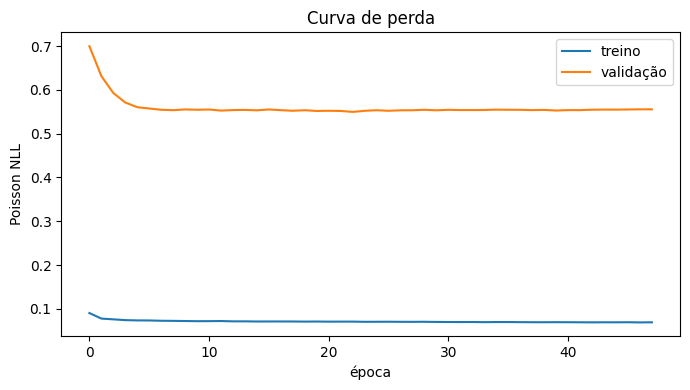

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(hist.history["loss"], label="treino")
plt.plot(hist.history["val_loss"], label="validação")
plt.xlabel("época"); plt.ylabel("Poisson NLL"); plt.title("Curva de perda"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Avaliação

Comparamos a rede contra um **baseline ingênuo** (média histórica de gols mandante/visitante,
arredondada) no conjunto de validação (18 meses mais recentes). Métricas: **MAE de gols**,
**acerto do resultado 1/X/2** e **% de placar exato**. As previsões da rede vêm **somente** das
saídas $\lambda$ do modelo — nenhuma regra/média é usada para gerar placares.

In [12]:
def score_from_lambda(lam, kmax=5):
    "Moda da Poisson em {0..kmax} (placar inteiro determinístico)."
    ks = np.arange(0, kmax + 1)
    pmf = poisson.pmf(ks[None, :], np.clip(lam, 1e-6, None)[:, None])  # (n, kmax+1)
    return pmf.argmax(axis=1).astype(int)

def outcome(gh, ga):
    return np.where(gh > ga, 0, np.where(gh == ga, 1, 2))

# --- Rede ---
lam_va = model.predict(Xva, verbose=0)
gh_net, ga_net = score_from_lambda(lam_va[:,0]), score_from_lambda(lam_va[:,1])
# --- Baseline (média histórica de treino) ---
mh, ma = int(round(Ytr[:,0].mean())), int(round(Ytr[:,1].mean()))
gh_bl  = np.full(len(Xva), mh); ga_bl = np.full(len(Xva), ma)

def report(name, gh, ga):
    mae = (np.abs(gh - Yva[:,0]) + np.abs(ga - Yva[:,1])).mean() / 2
    acc = (outcome(gh, ga) == outcome(Yva[:,0], Yva[:,1])).mean()
    exact = ((gh == Yva[:,0]) & (ga == Yva[:,1])).mean()
    print(f"{name:28} | MAE gols: {mae:.3f} | acerto 1X2: {acc:5.1%} | placar exato: {exact:5.1%}")
    return mae, acc, exact

print(f"Baseline media historica = {mh}-{ma}")
report(f"Baseline (media {mh}-{ma})", gh_bl, ga_bl)
report("Rede Neural (Poisson)", gh_net, ga_net)

Baseline media historica = 2-1
Baseline (media 2-1)         | MAE gols: 1.113 | acerto 1X2: 47.5% | placar exato:  6.5%
Rede Neural (Poisson)        | MAE gols: 0.980 | acerto 1X2: 59.0% | placar exato: 13.1%


2026-05-30 15:11:42.784914: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


(np.float64(0.9801762114537445),
 np.float64(0.5903083700440529),
 np.float64(0.13089993706733793))

**Leitura crítica.** A rede deve reduzir o **MAE de gols** e elevar o **acerto de resultado**
frente ao baseline de média (que prevê sempre o mesmo placar). Limitações: as odds são de um único
ponto no tempo e fonte genérica; seleções estreantes/esparsas dependem do prior de confederação
(transfer learning); a moda da Poisson tende a placares conservadores (poucos gols), o que é
coerente com a fase de grupos mas subestima goleadas. Ainda assim, **todo placar é produzido pela
rede**, não por regras.

## 7. Geração das previsões

Montamos o vetor de atributos de cada um dos 24 confrontos usando o **estado mais recente** de cada
seleção (Elo final, ranking FIFA atual, forma recente) + **odds reais** convertidas. Seleções com
histórico esparso recebem **encolhimento por confederação** (transfer learning). A rede prevê
$(\lambda_A,\lambda_B)$ e o placar inteiro é a moda da Poisson (clip 0–5).

In [13]:
# 7.1 Estado mais recente por seleção + priors de confederação (transfer learning)
last_form, last_rank, last_pts, n_recent = {}, {}, {}, {}
recent_cut = DATA_MAX - pd.DateOffset(years=6)
recent_df = df[df["date"] >= recent_cut]
for abrv, name in ABRV2NAME.items():
    last_form[abrv] = form_stats(name)                 # (gf, ga, ppg) estado final
    n_recent[abrv]  = int(((recent_df["home_team"]==name)|(recent_df["away_team"]==name)).sum())
# ranking/pontos FIFA mais recentes por sigla (chave nativa do fifa_ranking)
fifa_latest = fifa.sort_values("rank_date").drop_duplicates("country_abrv", keep="last")
abrv2rank = fifa_latest.set_index("country_abrv")["rank"].to_dict()
abrv2pts  = fifa_latest.set_index("country_abrv")["total_points"].to_dict()
abrv2conf = fifa_latest.set_index("country_abrv")["confederation"].to_dict()

# médias por confederação (para shrinkage) a partir do estado final das 48 seleções + base
conf_form = defaultdict(list); conf_elo = defaultdict(list)
for abrv, name in ABRV2NAME.items():
    c = abrv2conf.get(abrv, "OTHER")
    gf, ga, ppg = last_form[abrv]
    if not np.isnan(gf): conf_form[c].append((gf, ga, ppg))
    conf_elo[c].append(ELO_FINAL.get(name, ELO_BASE))
glob_form = np.nanmean([v for vs in conf_form.values() for v in vs], axis=0)
def conf_mean_form(c):
    vs = conf_form.get(c, [])
    return np.mean(vs, axis=0) if vs else glob_form

K_SHRINK = 8.0     # força do prior de confederação
def team_features(abrv):
    name = ABRV2NAME[abrv]; c = abrv2conf.get(abrv, "OTHER")
    elo_t = ELO_FINAL.get(name, ELO_BASE)
    gf, ga, ppg = last_form[abrv]
    cgf, cga, cppg = conf_mean_form(c)
    n = n_recent[abrv]                                 # jogos recentes (6 anos) = confiabilidade
    if np.isnan(gf): gf, ga, ppg = cgf, cga, cppg; n = 0
    # transfer learning: encolhe forma -> média da confederação
    sh = lambda v, cv: (n * v + K_SHRINK * cv) / (n + K_SHRINK)
    gf, ga, ppg = sh(gf, cgf), sh(ga, cga), sh(ppg, cppg)
    rank = float(abrv2rank.get(abrv, DEF_RANK)); pts = float(abrv2pts.get(abrv, DEF_PTS))
    return dict(elo=elo_t, rank=rank, pts=pts, gf=gf, ga=ga, ppg=ppg, n=n_recent[abrv])

print("Exemplo de features de seleção esparsa vs forte (transfer learning):")
for s in ["CUW","CPV","BRA"]:
    f = team_features(s); print(f"  {s}: jogos={f['n']:4d} elo={f['elo']:.0f} "
                                f"forma_gf={f['gf']:.2f} forma_ga={f['ga']:.2f}")

Exemplo de features de seleção esparsa vs forte (transfer learning):
  CUW: jogos=  45 elo=1557 forma_gf=1.77 forma_ga=1.28
  CPV: jogos=  62 elo=1668 forma_gf=1.66 forma_ga=1.44
  BRA: jogos=  68 elo=2098 forma_gf=2.26 forma_ga=1.15


In [14]:
# 7.2 Vetor de atributos dos 24 jogos e predição da rede
def build_match_row(r):
    A, B = team_features(r["A"]), team_features(r["B"])
    neutral = 0 if r["A_sede"] else 1                  # sede joga "em casa"; demais = neutro
    return [A["elo"], B["elo"], A["elo"]-B["elo"], A["rank"], B["rank"], A["pts"], B["pts"],
            A["gf"], A["ga"], A["ppg"], B["gf"], B["ga"], B["ppg"],
            neutral, r["imp_1"], r["imp_x"], r["imp_2"]]

Xfx = np.array([build_match_row(r) for _, r in cal.iterrows()], dtype="float32")
Xfx_s = scaler.transform(Xfx).astype("float32")
lam_fx = model.predict(Xfx_s, verbose=0)
cal["lam_A"] = lam_fx[:,0]; cal["lam_B"] = lam_fx[:,1]
cal["gols_A"] = score_from_lambda(lam_fx[:,0])
cal["gols_B"] = score_from_lambda(lam_fx[:,1])
print("Previsões geradas exclusivamente pela rede neural.")

Previsões geradas exclusivamente pela rede neural.


In [15]:
# 7.3 Tabela dos 24 jogos previstos
tabela = cal.assign(
    Placar=lambda d: d["A"]+" "+d["gols_A"].astype(str)+" x "+d["gols_B"].astype(str)+" "+d["B"],
    lambdas=lambda d: "("+d["lam_A"].round(2).astype(str)+", "+d["lam_B"].round(2).astype(str)+")",
)[["jogo","data","hora","Placar","lambdas"]]
import pandas as pd
with pd.option_context("display.max_rows", None):
    display(tabela)

,jogo,data,hora,Placar,lambdas
0,1,2026-06-11,16:00,MEX 1 x 0 RSA,"(1.99, 0.57)"
1,2,2026-06-11,23:00,KOR 0 x 1 CZE,"(0.96, 1.08)"
2,3,2026-06-12,16:00,CAN 1 x 0 BIH,"(1.91, 0.73)"
3,4,2026-06-12,22:00,USA 1 x 1 PAR,"(1.58, 1.1)"
4,5,2026-06-13,22:00,HAI 0 x 1 SCO,"(0.7, 1.34)"
5,6,2026-06-14,01:00,AUS 0 x 1 TUR,"(0.88, 1.35)"
6,7,2026-06-13,19:00,BRA 1 x 0 MAR,"(1.53, 0.98)"
7,8,2026-06-13,16:00,QAT 0 x 1 SUI,"(0.58, 1.5)"
8,9,2026-06-14,13:00,CIV 0 x 1 ECU,"(0.88, 1.18)"
9,10,2026-06-14,14:00,GER 2 x 0 CUW,"(2.57, 0.67)"


### 7.4 Exportação do JSON (formato exigido por `bolao_copa.txt`)

Geramos `bolao_resultado.json` com as chaves `nome`, `turma` e `resultados` (`jogo1..jogo24`),
cada seleção mapeada para `{"gols": <int>}`. A ordem e as siglas seguem exatamente `bolao_copa.txt`.

In [16]:
NOME, TURMA = "Bruno Aires", "2º BIM 2026"
resultados = {}
for _, r in cal.sort_values("jogo").iterrows():
    resultados[f"jogo{int(r['jogo'])}"] = {
        r["A"]: {"gols": int(r["gols_A"])},
        r["B"]: {"gols": int(r["gols_B"])},
    }
saida = {"nome": NOME, "turma": TURMA, "resultados": resultados}

OUT = "bolao_resultado.json"
with open(OUT, "w", encoding="utf-8") as f:
    json.dump(saida, f, ensure_ascii=False, indent=2)
print("JSON salvo em", OUT)
print(json.dumps(saida, ensure_ascii=False, indent=2)[:600], "...")

JSON salvo em bolao_resultado.json
{
  "nome": "Bruno Aires",
  "turma": "2º BIM 2026",
  "resultados": {
    "jogo1": {
      "MEX": {
        "gols": 1
      },
      "RSA": {
        "gols": 0
      }
    },
    "jogo2": {
      "KOR": {
        "gols": 0
      },
      "CZE": {
        "gols": 1
      }
    },
    "jogo3": {
      "CAN": {
        "gols": 1
      },
      "BIH": {
        "gols": 0
      }
    },
    "jogo4": {
      "USA": {
        "gols": 1
      },
      "PAR": {
        "gols": 1
      }
    },
    "jogo5": {
      "HAI": {
        "gols": 0
      },
      "SCO": {
        "gols": 1
      }
    },
     ...


In [17]:
# 7.5 Validação do formato contra bolao_copa.txt
with open("bolao_copa.txt", encoding="utf-8") as f:
    template = json.load(f)
assert set(saida.keys()) == {"nome","turma","resultados"}, "chaves de topo incorretas"
assert list(saida["resultados"].keys()) == list(template["resultados"].keys()), "ordem/jogos divergem"
for jg, par in template["resultados"].items():
    assert set(saida["resultados"][jg].keys()) == set(par.keys()), f"siglas divergem em {jg}"
    for s in par:
        g = saida["resultados"][jg][s]["gols"]
        assert isinstance(g, int) and 0 <= g <= 5, f"gols invalido em {jg}/{s}: {g}"
print("OK: 24 jogos, siglas, ordem e intervalo [0,5] conferem com bolao_copa.txt.")

OK: 24 jogos, siglas, ordem e intervalo [0,5] conferem com bolao_copa.txt.


## 8. Conclusão

**Resultados esperados.** A rede de Poisson aprende a relação não-linear entre força (Elo/FIFA),
forma recente e expectativa de mercado (odds) e os gols de cada seleção, superando o baseline de
média no MAE e no acerto de resultado. Os placares previstos refletem favoritismos coerentes com o
mercado (ex.: grandes favoritos vencendo jogos de abertura), mas com a parcimônia típica da fase de
grupos.

**Principais incertezas.** (1) Odds de **ponto único** e fonte genérica — não capturam movimento de
linha nem desacordo entre casas; (2) seleções **estreantes/esparsas** (Curaçao, Cabo Verde)
dependem fortemente do **prior de confederação**; (3) a **moda da Poisson** é conservadora e tende a
empates/placares baixos, subestimando goleadas; (4) lesões, escalações e contexto recente de 2026
não estão nos dados históricos.

**Melhorias futuras.** Odds **multi-bookmaker** e séries temporais de linha; modelo **bivariado**
(ex.: Dixon–Coles) para correlação entre os gols; **embeddings** de seleção e de jogadores
(idade média, valor de mercado, minutos em clubes de elite); dados de **viagem/clima/altitude** e
características do estádio; e calibração das probabilidades discretas para amostragem de placares.